# Thesis-Grade 1D Conditional Diffusion for ECG Refinement (v4 - Exhaustive Metrics)

### What is new in this version:
Calculates **every major metric** used in the state-of-the-art literature (*DeScoD-ECG, TFCDiff, PTB-IMAGE, VinDigitizer*) so your thesis has an undeniably rigorous evaluation section.

**The 12 Metrics Tracked:**
1. `Cosine_Sim`: Shape preservation.
2. `Pearson_r`: Linear correlation between signals.
3. `RMSE`: Root Mean Square Error.
4. `MAE`: Mean Absolute Error.
5. `SSD`: Sum of Squared Distances (DeScoD-ECG metric).
6. `MAD`: Maximum Absolute Distance (Crucial for proving spike removal).
7. `PRD`: Percentage Root-Mean-Square Difference.
8. `SNR`: Standard Signal-to-Noise Ratio.
9. `SNR_med`: Robust Median SNR.
10. `ImSNR`: Improved SNR (Difference between Noisy SNR and Denoised SNR).
11. `KS_Stat`: Kolmogorov-Smirnov distance (PTB-IMAGE metric).
12. `WAD`: Weighted Absolute Difference (PTB-IMAGE metric).

All 12 metrics are saved to `exhaustive_metrics_history.csv`.

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import welch
from scipy.stats import ks_2samp
import math
import os
from IPython.display import clear_output, display

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

PATH_CLEAN = '/kaggle/input/datasets/mukulbamn/7601-noisy-and-clean-paired-ecg-samples/clean_new_baseline.npy'
PATH_NOISY = '/kaggle/input/datasets/mukulbamn/7601-noisy-and-clean-paired-ecg-samples/noisy_new_baseline.npy'

Using device: cuda


In [26]:
class RealECGDataset(Dataset):
    def __init__(self, clean_npy_path, noisy_npy_path):
        if not os.path.exists(clean_npy_path) or not os.path.exists(noisy_npy_path):
            raise FileNotFoundError(f"Please upload {clean_npy_path} and {noisy_npy_path} to Colab.")
            
        self.clean_data = np.load(clean_npy_path).astype(np.float32)
        self.noisy_data = np.load(noisy_npy_path).astype(np.float32)
        
        if len(self.clean_data.shape) == 2:
            self.clean_data = np.expand_dims(self.clean_data, axis=1)
            self.noisy_data = np.expand_dims(self.noisy_data, axis=1)
            
        print(f"Dataset loaded! Shape: {self.clean_data.shape}")

    def __len__(self):
        return len(self.clean_data)

    def __getitem__(self, idx):
        clean = torch.tensor(self.clean_data[idx])
        noisy = torch.tensor(self.noisy_data[idx])
        return clean, noisy

In [27]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block1D(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU()
        )

    def forward(self, x, t):
        time_emb = self.mlp(t).unsqueeze(-1)
        return self.conv(x) + time_emb

class ConditionalUNet1D(nn.Module):
    def __init__(self, channels=1, time_emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )
        
        self.init_conv = nn.Conv1d(channels * 2, 64, kernel_size=7, padding=3)
        
        self.downs = nn.ModuleList([
            Block1D(64, 128, time_emb_dim),
            Block1D(128, 256, time_emb_dim)
        ])
        
        self.pool = nn.MaxPool1d(2)
        self.mid = Block1D(256, 256, time_emb_dim)
        
        self.ups = nn.ModuleList([
            Block1D(256 + 256, 128, time_emb_dim), 
            Block1D(128 + 128, 64, time_emb_dim)   
        ])
        
        self.up_sample = nn.Upsample(scale_factor=2, mode='linear', align_corners=False)
        self.final_conv = nn.Conv1d(64, channels, kernel_size=3, padding=1)

    def forward(self, x, t, cond):
        t = self.time_mlp(t)
        x = torch.cat([x, cond], dim=1) 
        x = self.init_conv(x)
        
        skip_connections = []
        for down in self.downs:
            x = down(x, t)
            skip_connections.append(x)
            x = self.pool(x)
            
        x = self.mid(x, t)
        
        for up in self.ups:
            x = self.up_sample(x)
            skip_x = skip_connections.pop()
            if x.shape[-1] != skip_x.shape[-1]:
                x = F.pad(x, (0, skip_x.shape[-1] - x.shape[-1]))
            x = torch.cat((x, skip_x), dim=1)
            x = up(x, t)
            
        return self.final_conv(x)

In [28]:
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

class GaussianDiffusion1D:
    def __init__(self, model, timesteps=500):
        self.model = model
        self.timesteps = timesteps
        self.betas = linear_beta_schedule(timesteps)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        
    def sample_timesteps(self, n, device):
        return torch.randint(low=1, high=self.timesteps, size=(n,), device=device)
        
    def add_noise(self, x_start, t):
        noise = torch.randn_like(x_start)
        alphas_cumprod_t = self.alphas_cumprod.to(x_start.device)[t].view(-1, 1, 1)
        x_noisy = torch.sqrt(alphas_cumprod_t) * x_start + torch.sqrt(1 - alphas_cumprod_t) * noise
        return x_noisy, noise

    def compute_loss(self, x_start, cond):
        device = x_start.device
        t = self.sample_timesteps(x_start.shape[0], device)
        x_noisy, noise = self.add_noise(x_start, t)
        predicted_noise = self.model(x_noisy, t, cond)
        return F.l1_loss(predicted_noise, noise)

    @torch.no_grad()
    def sample(self, cond):
        self.model.eval()
        device = cond.device
        b, c, l = cond.shape
        x = torch.randn((b, c, l), device=device)
        
        for i in reversed(range(1, self.timesteps)):
            t = (torch.ones(b) * i).long().to(device)
            predicted_noise = self.model(x, t, cond)
            
            alpha = self.alphas[i].to(device)
            alpha_cumprod = self.alphas_cumprod[i].to(device)
            beta = self.betas[i].to(device)
            
            if i > 1:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
                
            x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * predicted_noise) + torch.sqrt(beta) * noise
            
        self.model.train()
        return x

## Exhaustive Thesis Metrics & Visualizations

In [29]:
def calculate_exhaustive_metrics(clean, noisy, denoised):
    c = clean.cpu().numpy().squeeze()
    n = noisy.cpu().numpy().squeeze()
    d = denoised.cpu().numpy().squeeze()
    if len(c.shape) == 1:
        c, n, d = c[None, :], n[None, :], d[None, :]
        
    metrics = {}
    
    # 1. Cosine Similarity
    cos_sim = np.sum(c * d, axis=-1) / (np.linalg.norm(c, axis=-1) * np.linalg.norm(d, axis=-1) + 1e-8)
    metrics['Cosine_Sim'] = np.mean(cos_sim)
    
    # 2. Pearson R
    c_mean = np.mean(c, axis=-1, keepdims=True)
    d_mean = np.mean(d, axis=-1, keepdims=True)
    num = np.sum((c - c_mean) * (d - d_mean), axis=-1)
    den = np.sqrt(np.sum((c - c_mean)**2, axis=-1) * np.sum((d - d_mean)**2, axis=-1)) + 1e-8
    metrics['Pearson_r'] = np.mean(num / den)
    
    # 3. RMSE
    rmse = np.sqrt(np.mean((c - d)**2, axis=-1))
    metrics['RMSE'] = np.mean(rmse)
    
    # 4. MAE
    mae = np.mean(np.abs(c - d), axis=-1)
    metrics['MAE'] = np.mean(mae)
    
    # 5. SSD (DeScoD-ECG)
    ssd = np.sum((c - d)**2, axis=-1)
    metrics['SSD'] = np.mean(ssd)
    
    # 6. MAD (Maximum Absolute Distance)
    mad = np.max(np.abs(c - d), axis=-1)
    metrics['MAD'] = np.mean(mad)
    
    # 7. PRD
    prd = np.sqrt(np.sum((c - d)**2, axis=-1) / (np.sum(c**2, axis=-1) + 1e-8)) * 100
    metrics['PRD'] = np.mean(prd)
    
    # 8. SNR
    signal_power = np.mean(c**2, axis=-1)
    noise_power = np.mean((c - d)**2, axis=-1) + 1e-8
    snr = 10 * np.log10(signal_power / noise_power)
    metrics['SNR'] = np.mean(snr)
    
    # 9. SNR Median
    noise_power_med = np.median((c - d)**2, axis=-1) + 1e-8
    SNR_MED = 10 * np.log10(signal_power / noise_power_med)
    metrics['SNR_MED'] = np.mean(SNR_MED)
    
    # 10. Improved SNR (TFCDiff)
    noisy_noise_power = np.mean((c - n)**2, axis=-1) + 1e-8
    noisy_snr = 10 * np.log10(signal_power / noisy_noise_power)
    metrics['ImSNR'] = np.mean(snr - noisy_snr)
    
    # 11. KS Statistic (PTB-IMAGE)
    ks_vals = [ks_2samp(c[i], d[i]).statistic for i in range(c.shape[0])]
    metrics['KS_Stat'] = np.mean(ks_vals)
    
    # 12. WAD (Weighted Absolute Difference)
    ranges = (np.max(c, axis=-1) - np.min(c, axis=-1)) + 1e-8
    wad = np.mean(np.abs(c - d), axis=-1) / ranges
    metrics['WAD'] = np.mean(wad)

    return metrics

def plot_live_dashboard(clean, noisy, denoised, history, epoch, epochs):
    clear_output(wait=True)
    
    c = clean[0, 0].cpu().numpy()
    n = noisy[0, 0].cpu().numpy()
    d = denoised[0, 0].cpu().numpy()
    
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle(f"Training Dashboard - Epoch {epoch}/{epochs}", fontsize=20, fontweight='bold')

    # --- Row 1: Learning Curves ---
    ax1 = plt.subplot(4, 3, 1)
    ax1.plot(history['epoch'], history['loss'], color='purple', marker='o', markersize=4)
    ax1.set_title("Training Loss (L1)", fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    ax2 = plt.subplot(4, 3, 2)
    ax2.plot(history['epoch'], history['SNR_MED'], color='orange', marker='o', markersize=4)
    ax2.set_title("Median SNR Progression (dB)", fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    ax3 = plt.subplot(4, 3, 3)
    ax3.plot(history['epoch'], history['cos_sim'], color='green', marker='o', markersize=4)
    ax3.set_title("Cosine Similarity Progression", fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # --- Row 2: Full Signal Overlay ---
    ax4 = plt.subplot(4, 1, 2)
    ax4.plot(c, label="Ground Truth (Clean)", color="#2ca02c", alpha=0.8, linewidth=2)
    ax4.plot(n, label="Digitizer Output (Noisy)", color="#d62728", alpha=0.5, linestyle="--")
    ax4.plot(d, label="Diffusion Output (Denoised)", color="#1f77b4", alpha=0.9, linewidth=1.5)
    ax4.set_title("Full ECG Reconstruction", fontsize=14, fontweight='bold')
    ax4.legend(loc="upper right")
    ax4.grid(True, alpha=0.3)
    
    # --- Row 3: Zoomed QRS & Absolute Error ---
    peak_idx = np.argmax(c[:800]) 
    start, end = max(0, peak_idx - 50), min(len(c), peak_idx + 80)
    
    ax5 = plt.subplot(4, 2, 5)
    ax5.step(range(start, end), n[start:end], label="Noisy Extraction (Staircase)", color="#d62728", alpha=0.6, where='mid')
    ax5.plot(range(start, end), c[start:end], label="Clean Signal", color="#2ca02c", linewidth=2)
    ax5.plot(range(start, end), d[start:end], label="Diffusion Denoised", color="#1f77b4", linewidth=2)
    ax5.set_title("Zoomed QRS Complex (Staircase Smoothing)", fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    ax6 = plt.subplot(4, 2, 6)
    ax6.plot(np.abs(c - n), label="Digitizer Error |Clean - Noisy|", color="#d62728", alpha=0.5)
    ax6.plot(np.abs(c - d), label="Diffusion Error |Clean - Denoised|", color="#1f77b4", alpha=0.8)
    ax6.set_title("Absolute Error Distribution", fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # --- Row 4: Power Spectral Density (Frequency Domain) ---
    freqs_c, psd_c = welch(c, fs=500, nperseg=256)
    freqs_n, psd_n = welch(n, fs=500, nperseg=256)
    freqs_d, psd_d = welch(d, fs=500, nperseg=256)
    
    ax7 = plt.subplot(4, 1, 4)
    ax7.semilogy(freqs_n, psd_n, label="Noisy PSD (Digitizer Artifacts)", color="#d62728", alpha=0.6)
    ax7.semilogy(freqs_c, psd_c, label="Clean PSD (Ground Truth)", color="#2ca02c", linewidth=2)
    ax7.semilogy(freqs_d, psd_d, label="Denoised PSD (Diffusion Output)", color="#1f77b4", linewidth=2)
    ax7.set_title("Power Spectral Density (High-Frequency Noise Removal)", fontsize=14, fontweight='bold')
    ax7.set_xlabel("Frequency (Hz)")
    ax7.set_ylabel("Power/Frequency (dB/Hz)")
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"live_dashboard_epoch_{epoch}.png", dpi=300)
    plt.show()

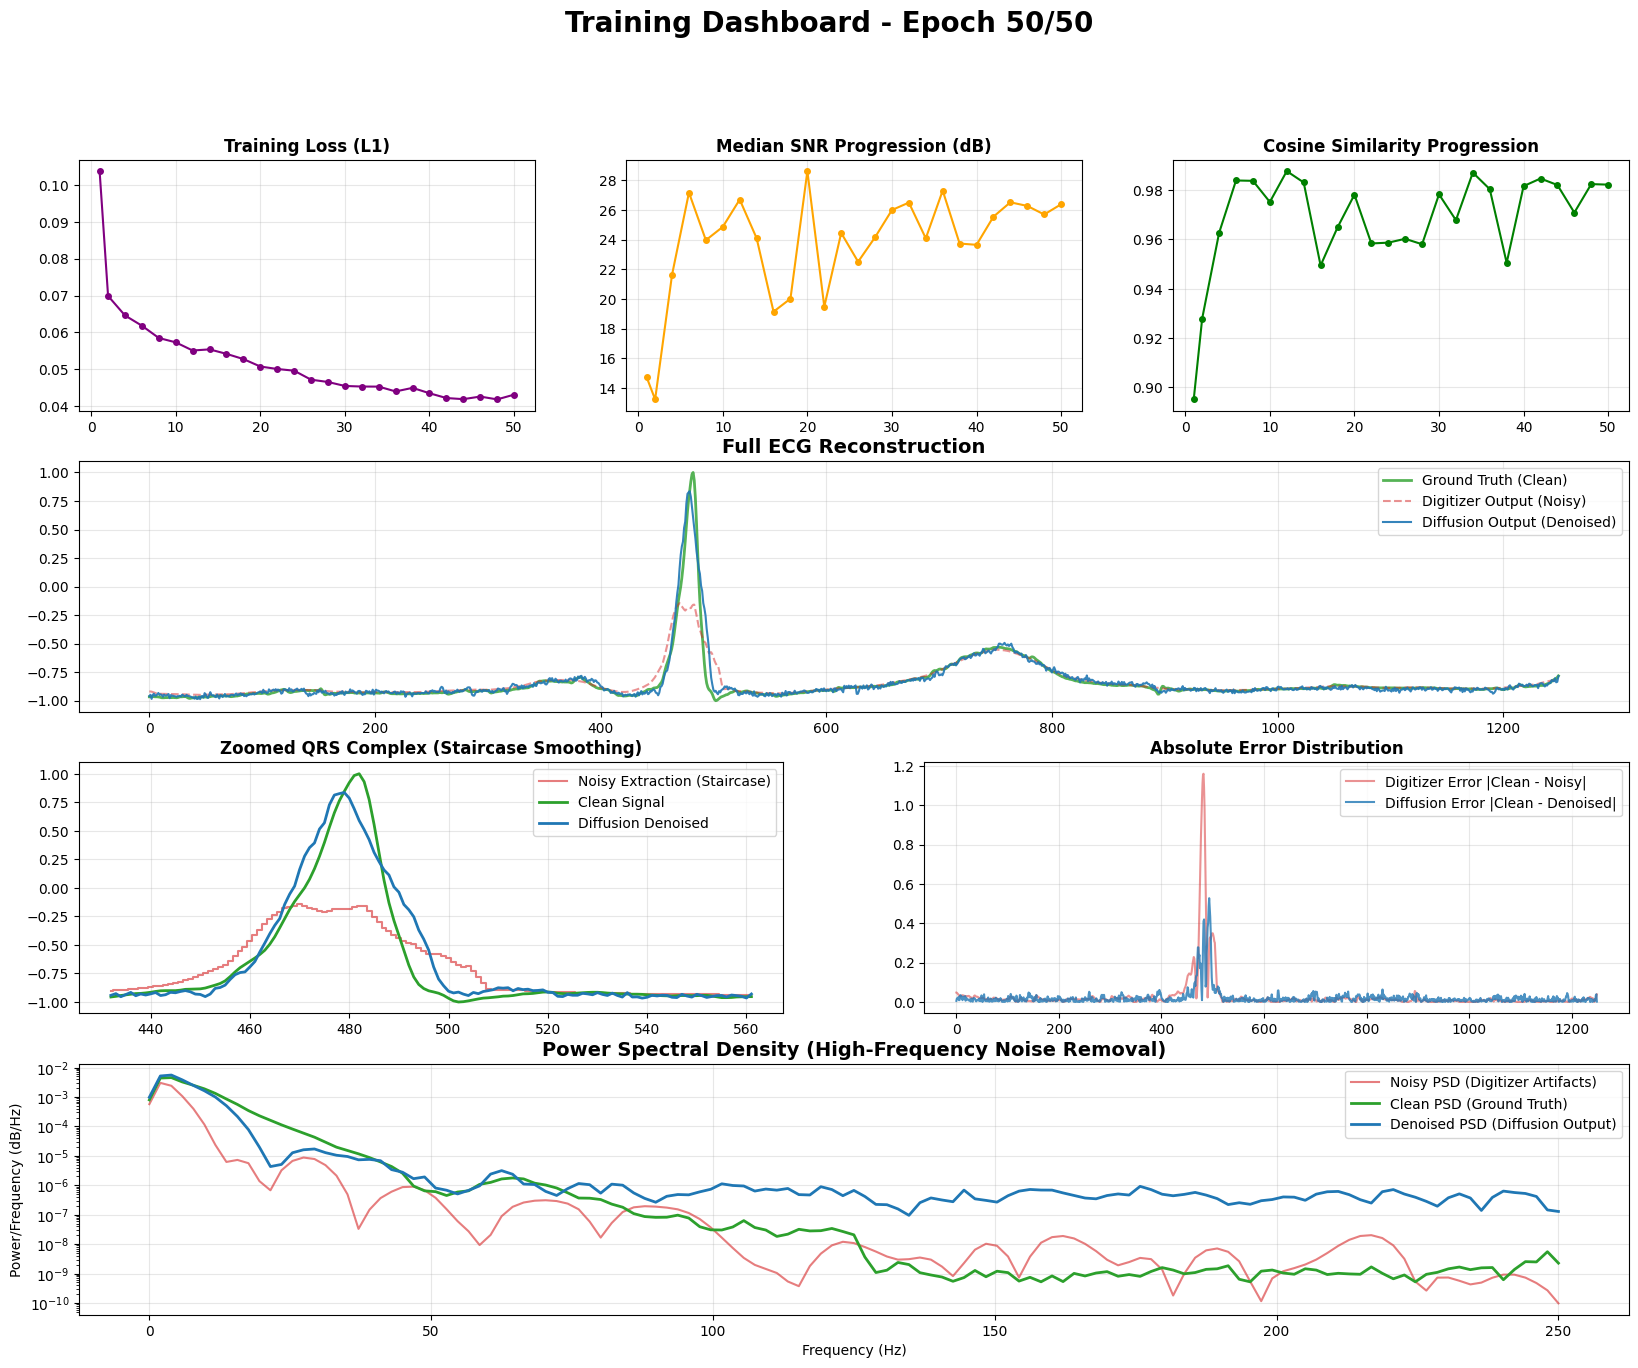


=== CURRENT METRICS ===
Loss: 0.0431 | LR: 0.000000
Cosine_Sim: 0.9822  | Pearson_r: 0.9457
SNR_MED:    26.37 dB | ImSNR:     0.85 dB
PRD:        16.87 %   | MAD:       0.6655
RMSE:       0.0858    | SSD:       9.8317
KS_Stat:    0.0876    | WAD:       0.0243


Training Complete! All 12 metrics saved to 'exhaustive_metrics_history.csv'


In [30]:
def train():
    try:
        dataset = RealECGDataset(PATH_CLEAN, PATH_NOISY)
    except FileNotFoundError as e:
        print(e)
        return

    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    
    model = ConditionalUNet1D(channels=1).to(device)
    diffusion = GaussianDiffusion1D(model, timesteps=500)
    
    optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    epochs = 50
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda')

    best_cos_sim = -1.0
    history = {k: [] for k in ['epoch', 'loss', 'Cosine_Sim', 'Pearson_r', 'RMSE', 'MAE', 'SSD', 'MAD', 'PRD', 'SNR', 'SNR_MED', 'ImSNR', 'KS_Stat', 'WAD']}
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        
        for batch_idx, (clean, cond) in enumerate(dataloader):
            clean = clean.to(device)
            cond = cond.to(device)
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                loss = diffusion.compute_loss(clean, cond)
                
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            
        scheduler.step()
        avg_loss = total_loss / len(dataloader)
        
        # Validation Step
        if epoch % 2 == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                val_cond = cond[:4]
                val_clean = clean[:4]
                denoised = diffusion.sample(val_cond)
                
                metrics = calculate_exhaustive_metrics(val_clean, val_cond, denoised)
                
                history['epoch'].append(epoch)
                history['loss'].append(avg_loss)
                for k, v in metrics.items():
                    history[k].append(v)
                # Add alias for the dashboard to read
                history['cos_sim'] = history['Cosine_Sim']
                
                if metrics['Cosine_Sim'] > best_cos_sim:
                    best_cos_sim = metrics['Cosine_Sim']
                    torch.save(model.state_dict(), 'best_diffusion_model.pth')
                
                plot_live_dashboard(val_clean, val_cond, denoised, history, epoch, epochs)
                
                print("\n=== CURRENT METRICS ===")
                print(f"Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")
                print(f"Cosine_Sim: {metrics['Cosine_Sim']:.4f}  | Pearson_r: {metrics['Pearson_r']:.4f}")
                print(f"SNR_MED:    {metrics['SNR_MED']:.2f} dB | ImSNR:     {metrics['ImSNR']:.2f} dB")
                print(f"PRD:        {metrics['PRD']:.2f} %   | MAD:       {metrics['MAD']:.4f}")
                print(f"RMSE:       {metrics['RMSE']:.4f}    | SSD:       {metrics['SSD']:.4f}")
                print(f"KS_Stat:    {metrics['KS_Stat']:.4f}    | WAD:       {metrics['WAD']:.4f}")
                print("=======================\n")

    # Remove the alias before saving to CSV to avoid duplication
    del history['cos_sim']
    pd.DataFrame(history).to_csv("exhaustive_metrics_history.csv", index=False)
    print("\nTraining Complete! All 12 metrics saved to 'exhaustive_metrics_history.csv'")

train()